In [ ]:
import sys
!{sys.executable} -m pip install pygraphviz

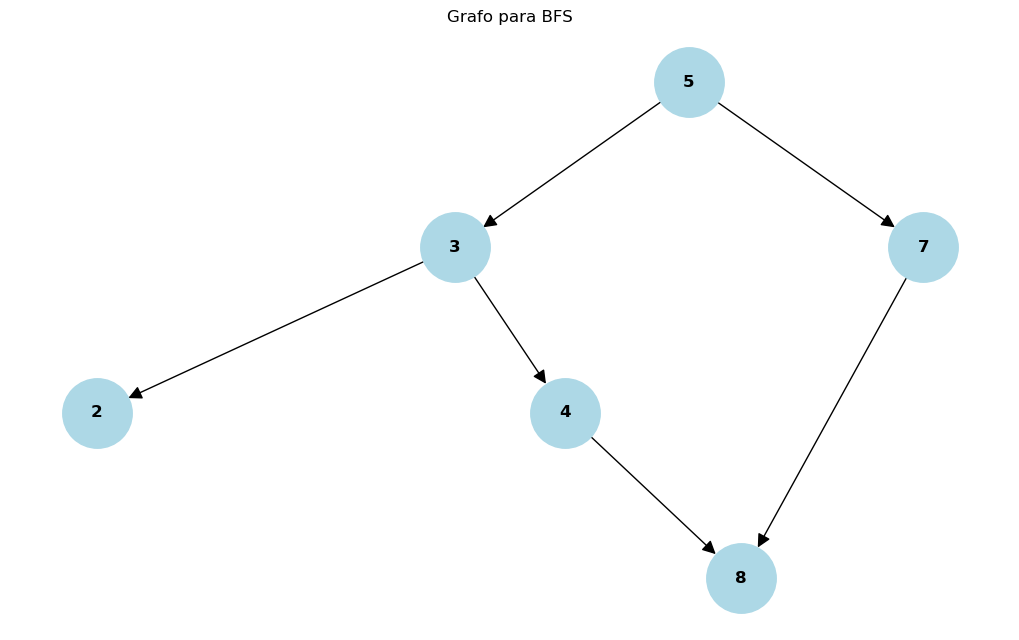


BFS: Izquierda a Derecha

Paso 1
Visitando nodo: 5
Ruta acumulada: 5
Cola antes de expandir: []
Cola después de expandir: ['3', '7']
-----------------------------------
Paso 2
Visitando nodo: 3
Ruta acumulada: 5 -> 3
Cola antes de expandir: ['7']
Cola después de expandir: ['7', '2', '4']
-----------------------------------
Paso 3
Visitando nodo: 7
Ruta acumulada: 5 -> 3 -> 7
Cola antes de expandir: ['2', '4']
Cola después de expandir: ['2', '4', '8']
-----------------------------------
Paso 4
Visitando nodo: 2
Ruta acumulada: 5 -> 3 -> 7 -> 2
Cola antes de expandir: ['4', '8']
Cola después de expandir: ['4', '8']
-----------------------------------
Paso 5
Visitando nodo: 4
Ruta acumulada: 5 -> 3 -> 7 -> 2 -> 4
Cola antes de expandir: ['8']
Cola después de expandir: ['8']
-----------------------------------
Paso 6
Visitando nodo: 8
Ruta acumulada: 5 -> 3 -> 7 -> 2 -> 4 -> 8
Cola antes de expandir: []

Objetivo 8 encontrado.

Recorrido final:
5 -> 3 -> 7 -> 2 -> 4 -> 8
Ruta al objetivo:

In [2]:

import pydot
from IPython.display import Image, display

import networkx as nx
import matplotlib.pyplot as plt

from networkx.drawing.nx_pydot import graphviz_layout
from collections import deque


# =====================================
# DEFINIMOS EL GRAFO
# =====================================
graph = {
    '5': ['3', '7'],
    '3': ['2', '4'],
    '7': ['8'],
    '2': [],
    '4': ['8'],
    '8': []
}


# =====================================
# MOSTRAR GRAFO GRÁFICAMENTE
# =====================================
G = nx.DiGraph()

for node, neighbours in graph.items():
    G.add_node(node)
    for neighbour in neighbours:
        G.add_edge(node, neighbour)

plt.figure(figsize=(10,6))

# Diseño jerárquico tipo árbol
pos = graphviz_layout(G, prog='dot')

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=2500,
    node_color='lightblue',
    font_size=12,
    font_weight='bold',
    arrows=True,
    arrowsize=20
)

plt.title("Grafo para BFS")
plt.show()


# =====================================
# FUNCIÓN BFS
# =====================================
def bfs(graph, root, goal=None, reverse=False):

    visited = set([root])
    queue = deque([root])
    parent = {root: None}
    recorrido = []

    direccion = "Derecha a Izquierda" if reverse else "Izquierda a Derecha"
    print("\n==============================")
    print("BFS:", direccion)
    print("==============================\n")

    paso = 1

    while queue:

        vertex = queue.popleft()
        recorrido.append(vertex)

        print(f"Paso {paso}")
        print(f"Visitando nodo: {vertex}")
        print(f"Ruta acumulada: {' -> '.join(recorrido)}")
        print(f"Cola antes de expandir: {list(queue)}")

        if goal is not None and vertex == goal:
            print(f"\nObjetivo {goal} encontrado.")
            break

        neighbours = list(graph[vertex])

        if reverse:
            neighbours.reverse()

        for neighbour in neighbours:
            if neighbour not in visited:
                visited.add(neighbour)
                parent[neighbour] = vertex
                queue.append(neighbour)

        print(f"Cola después de expandir: {list(queue)}")
        print("-----------------------------------")

        paso += 1


    # Reconstruir ruta al objetivo
    ruta = []

    if goal in parent:
        actual = goal

        while actual is not None:
            ruta.append(actual)
            actual = parent[actual]

        ruta.reverse()

    print("\nRecorrido final:")
    print(" -> ".join(recorrido))

    if ruta:
        print("Ruta al objetivo:")
        print(" -> ".join(ruta))

    return recorrido, ruta


# =====================================
# EJECUCIÓN
# =====================================

objetivo = '8'

# Izquierda a derecha
rec1, ruta1 = bfs(graph, '5', goal=objetivo, reverse=False)

# Derecha a izquierda
rec2, ruta2 = bfs(graph, '5', goal=objetivo, reverse=True)